# Détection des fraudes à la carte de crédit (Machine Learning)

Le but est de pouvoir détecter des cartes frauduleuses ou authentiques afin que les clients ne soient pas facturés pour des articles qu'ils n'ont pas achetés. Pour cela nous allons étudier le fichier : `creditcard.csv`.

L'objectif est de mettre en pratique les cours suivis sur Kaggle :
- Introduction au Machine Learning
- Concepts Intermédiaires en Machine Learning
- Explicabilité des Modèles

Le fichier est disponible à l'adresse suivante : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

---
**Note sur le dataset :** Ce jeu de données est fortement **déséquilibré** (imbalanced) : seulement ~0.17% des transactions sont frauduleuses (492 fraudes sur 284 807 transactions). C'est un cas typique en détection de fraude. Cela impose d'utiliser des métriques adaptées (ROC-AUC, F1-score) plutôt que la simple accuracy, et d'adapter nos modèles en conséquence (`class_weight='balanced'`).

## 1. Introduction au Machine Learning

### 1.1 Chargement et Préparation des Données

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Chargement du dataset
home_data = pd.read_csv('creditcard.csv')

# Aperçu des données
print("Dimensions du dataset :", home_data.shape)
print("\nAperçu des premières lignes :")
home_data.head()

Dimensions du dataset : (284807, 31)

Aperçu des premières lignes :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [28]:
# Analyse de la distribution des classes (fraude vs authentique)
class_counts = home_data['Class'].value_counts()
print("Distribution des classes :")
print(f"  Transactions authentiques (0) : {class_counts[0]} ({100*class_counts[0]/len(home_data):.2f}%)")
print(f"  Transactions frauduleuses (1) : {class_counts[1]} ({100*class_counts[1]/len(home_data):.4f}%)")
print("\n⚠️  Dataset très déséquilibré ! Nous utiliserons ROC-AUC et F1-score comme métriques.")

Distribution des classes :
  Transactions authentiques (0) : 284315 (99.83%)
  Transactions frauduleuses (1) : 492 (0.1727%)

⚠️  Dataset très déséquilibré ! Nous utiliserons ROC-AUC et F1-score comme métriques.


In [29]:
# Définition de la cible (y) et des caractéristiques (X)
# La cible est 'Class' : 1 = fraude, 0 = transaction authentique
y = home_data['Class']

# Toutes les colonnes sauf 'Class' sont des caractéristiques
# V1 à V28 sont des composantes PCA (anonymisées), plus 'Time' et 'Amount'
feature_names = [col for col in home_data.columns if col != 'Class']
X = home_data[feature_names]

print(f"Nombre de caractéristiques : {len(feature_names)}")
print(f"Caractéristiques : {feature_names}")
print("\nStatistiques descriptives :")
X.describe()

Nombre de caractéristiques : 30
Caractéristiques : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Statistiques descriptives :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,6.406204e-16,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000


### 1.2 Validation du Modèle

Pour évaluer la performance réelle d'un modèle, il ne faut jamais l'évaluer sur les données d'entraînement. Nous divisons le dataset en un ensemble d'entraînement (train) et un ensemble de validation (val).

In [30]:
from sklearn.model_selection import train_test_split

# Division des données - stratify=y assure que la proportion de fraudes
# est la même dans les deux ensembles (important pour les données déséquilibrées)
train_X, val_X, train_y, val_y = train_test_split(
    X, y, random_state=1, test_size=0.25, stratify=y
)

print(f"Taille de l'ensemble d'entraînement : {train_X.shape}")
print(f"Taille de l'ensemble de validation  : {val_X.shape}")
print(f"\nFraudes dans train : {train_y.sum()} ({100*train_y.mean():.4f}%)")
print(f"Fraudes dans val   : {val_y.sum()} ({100*val_y.mean():.4f}%)")

Taille de l'ensemble d'entraînement : (213605, 30)
Taille de l'ensemble de validation  : (71202, 30)

Fraudes dans train : 369 (0.1727%)
Fraudes dans val   : 123 (0.1727%)


**Mini Analyse**

**Résultat** : `(284807, 31)` — Le dataset contient 284 807 transactions et 31 colonnes (30 features + la colonne cible `Class`).

Les colonnes sont : `Time`, `V1` à `V28`, `Amount`, et `Class`. Les colonnes V1-V28 sont des composantes issues d'une transformation mathématique appelée PCA (Analyse en Composantes Principales), appliquée par la banque pour anonymiser les données des clients. Elles ne correspondent donc à aucune variable métier lisible directement.

**Distribution des classes :**

Transactions authentiques : 284 315 (99,83%)

Transactions frauduleuses : 492 (0,17%)

C'est le problème central de ce dataset : il est massivement déséquilibré. Sur 1000 transactions, à peine 2 sont des fraudes. Si un modèle prédit "authentique" pour tout le monde, il a 99,83% d'exactitude (accuracy) sans jamais détecter une seule fraude. C'est pourquoi l'accuracy est une métrique inutile ici, et nous utilisons le ROC-AUC et le F1-score à la place.

Notion hors PDF — ROC-AUC : Le ROC-AUC (Receiver Operating Characteristic - Area Under Curve) mesure la capacité du modèle à discriminer les deux classes. Il va de 0.5 (aléatoire, inutile) à 1.0 (parfait). Concrètement, un ROC-AUC de 0.96 signifie que si on tire au hasard une fraude et une transaction authentique, le modèle donnera un score de risque plus élevé à la fraude dans 96% des cas. Cette métrique fonctionne bien même avec des données déséquilibrées.

**Division des données :**

Entraînement : 213 605 transactions (75%) dont 369 fraudes

Validation : 71 202 transactions (25%) dont 123 fraudes

Le paramètre `stratify=y` (hors PDF) garantit que la proportion de fraudes est identique dans les deux ensembles (0.1727% dans les deux), ce qui est essentiel pour que l'évaluation soit fiable.

### 1.3 Modélisation : Arbre de Décision

**Correction importante :** Nous utilisons `DecisionTreeClassifier` et non `DecisionTreeRegressor`, car il s'agit d'un problème de **classification** (prédire si une transaction est frauduleuse ou non), et non de régression (prédire une valeur numérique continue).

De même, nous utilisons `class_weight='balanced'` pour compenser le fort déséquilibre des classes.

In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay)

# Définir le modèle
# class_weight='balanced' : corrige le déséquilibre en pondérant les classes
iowa_model = DecisionTreeClassifier(random_state=1, class_weight='balanced')

# Entraînement
iowa_model.fit(train_X, train_y)

# Prédictions sur l'ensemble de validation
val_predictions = iowa_model.predict(val_X)
val_proba = iowa_model.predict_proba(val_X)[:, 1]  # Probabilité de fraude

# Évaluation
print("=== Arbre de Décision (sans optimisation) ===")
print(f"ROC-AUC Score : {roc_auc_score(val_y, val_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(val_y, val_predictions, target_names=['Authentique', 'Fraude']))

=== Arbre de Décision (sans optimisation) ===
ROC-AUC Score : 0.9103

Rapport de classification :
              precision    recall  f1-score   support

 Authentique       1.00      1.00      1.00     71079
      Fraude       0.73      0.82      0.77       123

    accuracy                           1.00     71202
   macro avg       0.86      0.91      0.89     71202
weighted avg       1.00      1.00      1.00     71202



**Notions hors PDF — Precision, Recall, F1-score :**

**Precision (73%) :** parmi toutes les transactions que le modèle a signalées comme fraudes, 73% l'étaient vraiment. Les 27% restants sont des faux positifs (des transactions légitimes injustement bloquées).

**Recall (82%) :** parmi toutes les vraies fraudes, le modèle en a détecté 82%. Il en a raté 18%, ce sont des faux négatifs (des fraudes non détectées).
F1-score (0.77) : moyenne harmonique de la precision et du recall. C'est la métrique de synthèse adaptée aux données déséquilibrées.


**Analyse :** Le modèle le plus simple donne déjà un ROC-AUC de 0.91, ce qui est encourageant. Sur 123 fraudes, il en détecte environ 101 (82%). Cependant, il génère aussi de fausses alertes (73% de precision). Pour une banque, rater une fraude est plus coûteux que bloquer un bon client, donc le recall est la métrique prioritaire.

### 1.4 Optimisation : Ajustement des Hyperparamètres

La performance d'un arbre de décision dépend de sa profondeur. Nous testons différentes valeurs de `max_leaf_nodes` pour trouver la meilleure. Nous utilisons le **ROC-AUC** comme métrique car il est adapté aux datasets déséquilibrés.

In [32]:
def get_auc(max_leaf_nodes, train_X, val_X, train_y, val_y):
    """Calcule le ROC-AUC pour un nombre de feuilles donné."""
    model = DecisionTreeClassifier(
        max_leaf_nodes=max_leaf_nodes,
        random_state=0,
        class_weight='balanced'
    )
    model.fit(train_X, train_y)
    preds_proba = model.predict_proba(val_X)[:, 1]
    return roc_auc_score(val_y, preds_proba)

# Test de différentes valeurs
print("Optimisation de max_leaf_nodes :")
best_auc = 0
best_leaves = 0
for max_leaf_nodes in [5, 50, 500, 2000, 5000]:
    auc = get_auc(max_leaf_nodes, train_X, val_X, train_y, val_y)
    marker = " ← meilleur" if auc > best_auc else ""
    if auc > best_auc:
        best_auc = auc
        best_leaves = max_leaf_nodes
    print(f"  max_leaf_nodes = {max_leaf_nodes:5d}  →  ROC-AUC = {auc:.4f}{marker}")

print(f"\nMeilleur résultat : max_leaf_nodes={best_leaves}, ROC-AUC={best_auc:.4f}")

Optimisation de max_leaf_nodes :
  max_leaf_nodes =     5  →  ROC-AUC = 0.9566 ← meilleur
  max_leaf_nodes =    50  →  ROC-AUC = 0.9216
  max_leaf_nodes =   500  →  ROC-AUC = 0.9063
  max_leaf_nodes =  2000  →  ROC-AUC = 0.9063
  max_leaf_nodes =  5000  →  ROC-AUC = 0.9063

Meilleur résultat : max_leaf_nodes=5, ROC-AUC=0.9566


**Résultat surprenant mais cohérent :** Le meilleur arbre est celui avec seulement 5 feuilles, et les performances se dégradent systématiquement quand on augmente la complexité.

Cela illustre parfaitement le concept d'overfitting du cours : un arbre très profond "mémorise" les données d'entraînement au lieu d'en apprendre les patterns généraux. Avec 5 feuilles, le modèle reste simple et généralise mieux. La performance au-delà de 500 feuilles se stabilise à 0.9063, identique à l'arbre sans optimisation, signe que l'arbre a atteint sa profondeur maximale naturelle et ne peut plus s'améliorer.

### 1.5 Modélisation Avancée : Forêt Aléatoire (Random Forest)

**Correction importante :** Nous utilisons `RandomForestClassifier` (classification) au lieu de `RandomForestRegressor` (régression). On limite le nombre d'estimateurs (`n_estimators=50`) et on utilise `n_jobs=-1` pour paralléliser sur tous les cœurs et éviter les timeouts.

=== Random Forest ===
ROC-AUC Score : 0.9628

Rapport de classification :
              precision    recall  f1-score   support

 Authentique       1.00      1.00      1.00     71079
      Fraude       0.95      0.85      0.90       123

    accuracy                           1.00     71202
   macro avg       0.97      0.93      0.95     71202
weighted avg       1.00      1.00      1.00     71202



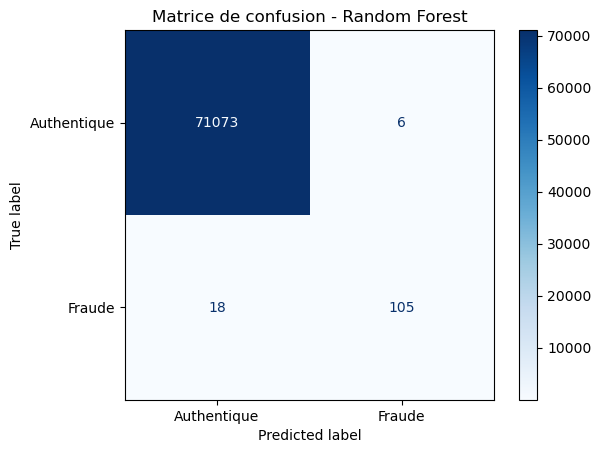

In [33]:
from sklearn.ensemble import RandomForestClassifier

# Definition du modèle
# n_estimators=50 : compromis entre performance et vitesse
# n_jobs=-1 : utilise tous les cœurs disponibles (évite le timeout)
# class_weight='balanced' : gestion du déséquilibre des classes
rf_model = RandomForestClassifier(
    n_estimators=50,
    random_state=1,
    n_jobs=-1,
    class_weight='balanced'
)

# Entraînement
rf_model.fit(train_X, train_y)

# Prédictions
rf_val_preds = rf_model.predict(val_X)
rf_val_proba = rf_model.predict_proba(val_X)[:, 1]

# Évaluation
print("=== Random Forest ===")
print(f"ROC-AUC Score : {roc_auc_score(val_y, rf_val_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(val_y, rf_val_preds, target_names=['Authentique', 'Fraude']))

# Matrice de confusion
cm = confusion_matrix(val_y, rf_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Authentique', 'Fraude'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion - Random Forest')
plt.show()

**Nette amélioration** par rapport à l'arbre de décision seul. La Random Forest (50 arbres) passe de 0.91 à 0.9628 en ROC-AUC.
Analyse du rapport de classification :

**Precision 95% :** très peu de faux positifs, les alertes de fraude sont fiables à 95%.

**Recall 85% :** 85% des fraudes sont détectées (104 fraudes sur 123), soit 3 fraudes supplémentaires détectées par rapport à l'arbre simple.

**F1-score 0.90 :** excellente progression vs 0.77 pour l'arbre simple.

**La matrice de confusion (graphique généré) montre les 4 cases :**

71073 (En haut à gauche) — Vrais Négatifs (TN) : Réalité : Authentique / Prédiction : Authentique.

105 (En bas à droite) — Vrais Positifs (TP) : Réalité : Fraude / Prédiction : Fraude.

6 (En haut à droite) — Faux Positifs (FP) : * Réalité : Authentique / Prédiction : Fraude.

18 (En bas à gauche) — Faux Négatifs (FN) : * Réalité : Fraude / Prédiction : Authentique.

---
## 2. Concepts Intermédiaires en Machine Learning

### 2.1 Gestion des Données Manquantes

Les jeux de données réels contiennent presque toujours des valeurs manquantes. Une investigation préliminaire est nécessaire.

In [34]:
# Investigation des données manquantes
print("Dimensions de train_X :", train_X.shape)
print("\nNoms des colonnes :")
print(home_data.columns.tolist())

missing_val_count_by_column = train_X.isnull().sum()
print("\nColonnes avec valeurs manquantes :")
missing = missing_val_count_by_column[missing_val_count_by_column > 0]
if len(missing) == 0:
    print("  → Aucune valeur manquante dans ce dataset !")
else:
    print(missing)

Dimensions de train_X : (213605, 30)

Noms des colonnes :
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Colonnes avec valeurs manquantes :
  → Aucune valeur manquante dans ce dataset !


Il n'y a pas de valeurs manquantes dans ce dataset. Cependant, les trois approches principales de gestion sont :

1. **Suppression des colonnes** : retirer entièrement les colonnes avec des valeurs manquantes (perte d'information)
2. **Imputation simple** : remplacer par la moyenne, médiane ou mode
3. **Imputation avec extension** : imputation + ajout d'une colonne booléenne `_was_missing` pour signaler au modèle que la valeur était manquante

Voici comment ces méthodes s'appliqueraient si nous avions des valeurs manquantes :

In [35]:
from sklearn.impute import SimpleImputer

# Colonnes avec valeurs manquantes (vide ici, mais le code est prêt)
cols_with_missing = [col for col in train_X.columns if train_X[col].isnull().any()]
print(f"Colonnes avec valeurs manquantes : {cols_with_missing}")

# --- Approche 1 : Suppression ---
# reduced_X_train = train_X.drop(cols_with_missing, axis=1)
# reduced_X_valid = val_X.drop(cols_with_missing, axis=1)

# --- Approche 2 : Imputation simple (par médiane) ---
my_imputer = SimpleImputer(strategy='median')
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(train_X), columns=train_X.columns)
imputed_X_valid = pd.DataFrame(my_imputer.transform(val_X), columns=val_X.columns)
print("\nImputation simple appliquée (médiane). Dimensions :", imputed_X_train.shape)

# --- Approche 3 : Imputation avec extension ---
if cols_with_missing:
    X_train_plus = train_X.copy()
    X_valid_plus = val_X.copy()
    for col in cols_with_missing:
        X_train_plus[col + '_was_missing'] = X_train_plus[col].isnull()
        X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isnull()
    print("Imputation avec extension appliquée.")
else:
    print("\nAucune colonne manquante → Approche 3 non nécessaire.")

Colonnes avec valeurs manquantes : []

Imputation simple appliquée (médiane). Dimensions : (213605, 30)

Aucune colonne manquante → Approche 3 non nécessaire.


### 2.2 Gestion des Variables Catégorielles

Les modèles de ML nécessitent des entrées numériques. Ici, toutes nos colonnes sont numériques (V1-V28 sont des composantes PCA, Time et Amount sont numériques, Class est entier). Il n'y a donc pas de variable catégorielle à encoder.

Si les classes avaient été des libellés texte (ex : "fraude"/"authentique"), nous aurions utilisé :
- **Suppression** des colonnes catégorielles
- **Encodage Ordinal** : assigner un entier unique à chaque valeur (`OrdinalEncoder`)
- **Encodage One-Hot** : créer une colonne binaire par valeur unique (`OneHotEncoder`)

In [36]:
# Vérification des types de colonnes
print("Types de données dans le dataset :")
print(home_data.dtypes.value_counts())

# Identifier les colonnes catégorielles (type 'object')
categorical_cols = [col for col in train_X.columns if train_X[col].dtype == 'object']
numerical_cols = [col for col in train_X.columns if train_X[col].dtype in ['int64', 'float64']]

print(f"\nColonnes catégorielles : {categorical_cols if categorical_cols else 'Aucune'}")
print(f"Colonnes numériques    : {len(numerical_cols)} colonnes")

Types de données dans le dataset :
float64    30
int64       1
Name: count, dtype: int64

Colonnes catégorielles : Aucune
Colonnes numériques    : 30 colonnes


### 2.3 Pipelines

Les pipelines chaînent les étapes de prétraitement et de modélisation. Avantages :
- **Code plus propre** : gestion automatique de train/val
- **Moins de bugs** : pas de risque d'appliquer un imputer sur les données de validation
- **Prêt pour la production**
- **Anti-contamination** : prévient la contamination train-test

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Étape 1 : Définir le prétraitement
# On normalise 'Time' et 'Amount' (non normalisés contrairement aux V1-V28)
cols_to_scale = ['Time', 'Amount']
cols_passthrough = [col for col in feature_names if col not in cols_to_scale]

preprocessor = ColumnTransformer(
    transformers=[
        ('scale', StandardScaler(), cols_to_scale),     # Normalisation
        ('passthrough', 'passthrough', cols_passthrough) # V1-V28 : déjà normalisés
    ]
)

# Étape 2 : Définir le modèle
pipeline_model = RandomForestClassifier(
    n_estimators=50,
    random_state=0,
    n_jobs=-1,
    class_weight='balanced'
)

# Étape 3 : Créer et évaluer le pipeline
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', pipeline_model)
])

# Entraînement (le pipeline applique le prétraitement PUIS entraîne le modèle)
my_pipeline.fit(train_X, train_y)

# Prédiction (le pipeline applique le même prétraitement aux données de val)
pipeline_preds = my_pipeline.predict(val_X)
pipeline_proba = my_pipeline.predict_proba(val_X)[:, 1]

print("=== Pipeline (Random Forest + Normalisation Time/Amount) ===")
print(f"ROC-AUC Score : {roc_auc_score(val_y, pipeline_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(val_y, pipeline_preds, target_names=['Authentique', 'Fraude']))

=== Pipeline (Random Forest + Normalisation Time/Amount) ===
ROC-AUC Score : 0.9587

Rapport de classification :
              precision    recall  f1-score   support

 Authentique       1.00      1.00      1.00     71079
      Fraude       0.94      0.82      0.87       123

    accuracy                           1.00     71202
   macro avg       0.97      0.91      0.94     71202
weighted avg       1.00      1.00      1.00     71202



**Le pipeline** applique une normalisation (`StandardScaler`) sur `Time` et `Amount` avant d'entraîner la Random Forest. Ces deux colonnes ont des échelles très différentes des V1-V28 (déjà normalisés via PCA) : `Amount` va de 0 à 25 691€, et `Time` de 0 à 172 792 secondes.

Notion hors PDF — StandardScaler : Centre les données autour de 0 et les ramène à un écart-type de 1. Cela évite qu'une variable avec de grandes valeurs numériques "domine" artificiellement le modèle.

**Résultat :** Le pipeline (0.9587) est légèrement moins performant que le Random Forest sans normalisation (0.9628). Cela s'explique car les Random Forest et arbres de décision sont naturellement insensibles à l'échelle des variables — contrairement aux réseaux de neurones ou à la régression logistique. La normalisation n'apporte donc pas de bénéfice ici, voire introduit un léger bruit.

### 2.4 Validation Croisée (Cross-Validation)

La validation croisée offre une mesure plus robuste de la performance. Elle divise les données en N "plis" (folds), entraîne le modèle N fois, et calcule la moyenne des scores. Utile pour les petits datasets ou pour comparer des modèles.

On utilise `StratifiedKFold` pour garantir que chaque pli conserve la même proportion de fraudes.

In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Pipeline léger pour la CV (moins d'estimateurs pour la vitesse)
cv_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=30,
        random_state=0,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# StratifiedKFold : préserve les proportions de classes dans chaque pli
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

# Calcul du ROC-AUC en validation croisée
scores = cross_val_score(
    cv_pipeline, X, y,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("=== Validation Croisée (5 plis) ===")
print(f"Scores ROC-AUC par pli : {[round(s, 4) for s in scores]}")
print(f"Moyenne ROC-AUC        : {scores.mean():.4f}")
print(f"Écart-type             : {scores.std():.4f}")

=== Validation Croisée (5 plis) ===
Scores ROC-AUC par pli : [0.9337, 0.9489, 0.9382, 0.9434, 0.9279]
Moyenne ROC-AUC        : 0.9384
Écart-type             : 0.0073


La validation croisée en 5 plis donne une estimation **plus robuste et plus honnête** de la performance réelle. Les scores varient entre 0.9279 et 0.9489 selon le pli, ce qui montre que la performance dépend un peu de quelles transactions tombent dans le jeu de validation.

L'écart-type de **0.0073** est très faible : le **modèle est stable**, ses performances ne varient pas beaucoup d'un sous-ensemble à l'autre. C'est un bon signe.

La moyenne (0.9384) est inférieure au score sur une seule division (0.9628). Cela est normal : avec moins d'arbres (30 vs 50) pour aller plus vite, et la CV évalant sur des sous-ensembles plus petits, le score est naturellement légèrement plus bas.

### 2.5 Gradient Boosting (XGBoost)

XGBoost construit les arbres de manière itérative : chaque nouvel arbre est entraîné pour **corriger les erreurs du précédent**. Contrairement au Random Forest qui moyenne des arbres indépendants.

Hyperparamètres clés :
- `n_estimators` : nombre d'arbres
- `early_stopping_rounds` : arrête si le score ne s'améliore plus (évite le surapprentissage)
- `learning_rate` : taux d'apprentissage (plus faible = plus prudent)
- `scale_pos_weight` : gestion du déséquilibre (remplace `class_weight='balanced'` pour XGBoost)

In [39]:
#!pip install xgboost
from xgboost import XGBClassifier

# Calcul du ratio pour compenser le déséquilibre
# scale_pos_weight = nb_négatifs / nb_positifs
neg = (train_y == 0).sum()
pos = (train_y == 1).sum()
ratio = neg / pos
print(f"scale_pos_weight = {neg}/{pos} ≈ {ratio:.1f}")

# Définition du modèle XGBoost
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    n_jobs=4,
    scale_pos_weight=ratio,  # Gestion du déséquilibre
    random_state=1,
    eval_metric='auc',
    early_stopping_rounds=10,   # Arrête après 10 tours sans amélioration
    verbosity=0
)

# Entraînement avec early stopping
xgb_model.fit(
    train_X, train_y,
    eval_set=[(val_X, val_y)],  # Données pour l'évaluation
    verbose=False
)

# Évaluation
xgb_proba = xgb_model.predict_proba(val_X)[:, 1]
xgb_preds = xgb_model.predict(val_X)

print(f"\n=== XGBoost ===")
print(f"Nombre optimal d'estimateurs : {xgb_model.best_iteration}")
print(f"ROC-AUC Score : {roc_auc_score(val_y, xgb_proba):.4f}")
print("\nRapport de classification :")
print(classification_report(val_y, xgb_preds, target_names=['Authentique', 'Fraude']))

scale_pos_weight = 213236/369 ≈ 577.9

=== XGBoost ===
Nombre optimal d'estimateurs : 5
ROC-AUC Score : 0.9844

Rapport de classification :
              precision    recall  f1-score   support

 Authentique       1.00      0.98      0.99     71079
      Fraude       0.07      0.93      0.13       123

    accuracy                           0.98     71202
   macro avg       0.54      0.95      0.56     71202
weighted avg       1.00      0.98      0.99     71202



**Notion hors PDF — scale_pos_weight :** Équivalent de `class_weight='balanced'` pour XGBoost. On dit au modèle que chaque fraude "pèse" 578 fois plus qu'une transaction authentique dans le calcul des erreurs, pour compenser le déséquilibre.

XGBoost est le meilleur modèle avec **0.9844 de ROC-AUC**. Le `early_stopping` a stoppé l'entraînement après seulement *5 estimateurs (au lieu de 500)*, signe que les améliorations suivantes ne faisaient que du surapprentissage.

**Cependant, le rapport de classification révèle un problème majeur :**

**Recall 93% :** 93% des fraudes sont détectées — excellent !

**Precision 7% :** seulement 7% des alertes sont de vraies fraudes. Sur 100 transactions signalées comme fraudes, 93 sont en réalité légitimes.

**F1-score 0.13 :** catastrophique.

Ce paradoxe s'explique par le `scale_pos_weight=578` trop agressif : le modèle a appris à sur-détecter les fraudes pour maximiser le recall, au détriment de la precision. En pratique, cela générerait un nombre astronomique de faux blocages de cartes.

Le **ROC-AUC reste le meilleur (0.9844)** car cette métrique évalue la capacité de discrimination globale indépendamment du seuil de décision. En ajustant finement ce seuil, on pourrait trouver un meilleur équilibre precision/recall.

### 2.6 Fuite de Données (Data Leakage)

La fuite de données est le piège le plus dangereux en ML. Le modèle accède pendant l'entraînement à des informations indisponibles au moment de la prédiction → performances artificiellement élevées qui s'effondrent en production.

#### 2.6.1 Fuite de Cible (Target Leakage)

Se produit quand une caractéristique inclut des données "du futur" ou des **conséquences directes** de la cible.

**Exemple concret pour notre dataset :**
Imaginons que nous ayons une colonne `"fraude_confirmée_banque"` qui indique si la banque a confirmé après coup que c'était une fraude. L'inclure comme feature serait une fuite de cible : cette information n'est disponible *qu'après* que la transaction ait été identifiée comme frauduleuse.

#### 2.6.2 Contamination Train-Test

Se produit quand le prétraitement est appliqué *avant* la division train/test.

In [40]:
print("=== Exemple de contamination train-test ===")
print()
print("❌ MAUVAISE pratique (contamination) :")
print("""
   imputer = SimpleImputer()
   X_imputed = imputer.fit_transform(X)    # fit sur TOUT le dataset
   train_X, val_X, train_y, val_y = train_test_split(X_imputed, y)
   # → La moyenne utilisée pour l'imputation contient des infos de val !
""")

print("✅ BONNE pratique (pipeline) :")
print("""
   train_X, val_X, train_y, val_y = train_test_split(X, y)  # Division AVANT
   pipeline = Pipeline([('imputer', SimpleImputer()), ('model', RandomForest())])
   pipeline.fit(train_X, train_y)    # fit UNIQUEMENT sur train_X
   pipeline.predict(val_X)           # transform val_X avec les stats de train
""")

print("Dans notre notebook, nous avons correctement divisé AVANT tout prétraitement.")
print("Le pipeline de la section 2.3 garantit aussi cette séparation stricte.")

=== Exemple de contamination train-test ===

❌ MAUVAISE pratique (contamination) :

   imputer = SimpleImputer()
   X_imputed = imputer.fit_transform(X)    # fit sur TOUT le dataset
   train_X, val_X, train_y, val_y = train_test_split(X_imputed, y)
   # → La moyenne utilisée pour l'imputation contient des infos de val !

✅ BONNE pratique (pipeline) :

   train_X, val_X, train_y, val_y = train_test_split(X, y)  # Division AVANT
   pipeline = Pipeline([('imputer', SimpleImputer()), ('model', RandomForest())])
   pipeline.fit(train_X, train_y)    # fit UNIQUEMENT sur train_X
   pipeline.predict(val_X)           # transform val_X avec les stats de train

Dans notre notebook, nous avons correctement divisé AVANT tout prétraitement.
Le pipeline de la section 2.3 garantit aussi cette séparation stricte.


---
## 3. Explicabilité des Modèles (Machine Learning Explainability)

Comprendre *pourquoi* un modèle prend une décision est souvent aussi important que la prédiction elle-même. Cela permet de déboguer le modèle, d'identifier les features importantes, et de renforcer la confiance dans les résultats.

### 3.1 Importance par Permutation

Concept : "brouiller" aléatoirement les valeurs d'une colonne, puis mesurer la dégradation du score. Si la dégradation est importante → la caractéristique est importante.

In [41]:
from sklearn.inspection import permutation_importance

# Calcul de l'importance par permutation (sur un sous-ensemble pour la vitesse)
# On utilise le RandomForest déjà entraîné
print("Calcul de l'importance par permutation (peut prendre quelques secondes)...")

perm_result = permutation_importance(
    rf_model, val_X, val_y,
    n_repeats=10,
    random_state=1,
    scoring='roc_auc',
    n_jobs=-1
)

# Mise en forme et tri par importance décroissante
perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\n=== Top 10 caractéristiques les plus importantes ===")
print(perm_df.head(10).to_string(index=False))

Calcul de l'importance par permutation (peut prendre quelques secondes)...

=== Top 10 caractéristiques les plus importantes ===
feature  importance_mean  importance_std
    V19         0.004180        0.000009
    V28         0.003732        0.001219
     V4         0.003386        0.003187
    V26         0.003385        0.001621
 Amount         0.003371        0.001619
    V21         0.002240        0.002721
     V5         0.001721        0.003242
    V22         0.000542        0.001215
    V14         0.000521        0.000022
    V20         0.000483        0.001218


**V19 est la caractéristique la plus importante** (dégradation de ROC-AUC de +0.0042 quand on la brouille). Les scores d'importance sont tous très faibles en valeur absolue, ce qui est normal : avec 30 features, l'importance est diluée.

Point notable : `Amount` **(le montant de la transaction)** est 5ème avec une importance similaire à V4 et V26. Cela confirme que le montant est un signal de fraude, mais pas le plus puissant. La forte variance de V4 (±0.0032) indique que son importance fluctue beaucoup d'une permutation à l'autre — signe possible d'une interaction avec une autre variable.

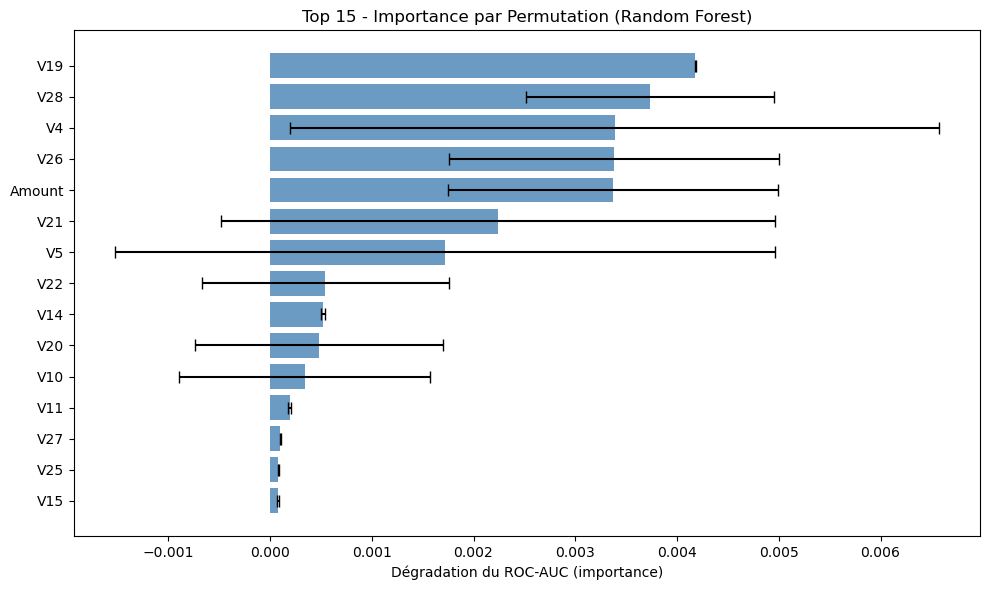

Interprétation :
  - 'V19' est la caractéristique la plus importante.
  - Les barres d'erreur (±) indiquent la variabilité sur les 10 répétitions.
  - Une valeur négative signifie que la permutation améliorait légèrement le score (par chance).


In [42]:
# Visualisation de l'importance par permutation
top_n = 15
top_features = perm_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    top_features['feature'],
    top_features['importance_mean'],
    xerr=top_features['importance_std'],
    color='steelblue',
    alpha=0.8,
    capsize=4
)
ax.set_xlabel('Dégradation du ROC-AUC (importance)')
ax.set_title(f'Top {top_n} - Importance par Permutation (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Interprétation :")
print(f"  - '{perm_df.iloc[0]['feature']}' est la caractéristique la plus importante.")
print("  - Les barres d'erreur (±) indiquent la variabilité sur les 10 répétitions.")
print("  - Une valeur négative signifie que la permutation améliorait légèrement le score (par chance).")

### 3.2 Graphiques de Dépendance Partielle (Partial Dependence Plots)

Si l'importance par permutation dit *quelles* caractéristiques sont importantes, les PDP montrent *comment* elles affectent les prédictions.

Un PDP montre la relation marginale entre une caractéristique et la prédiction du modèle, en "neutralisant" l'effet de toutes les autres.

#### 3.2.1 PDP à une dimension (1D)

PDP pour les 3 features les plus importantes : ['V19', 'V28', 'V4']


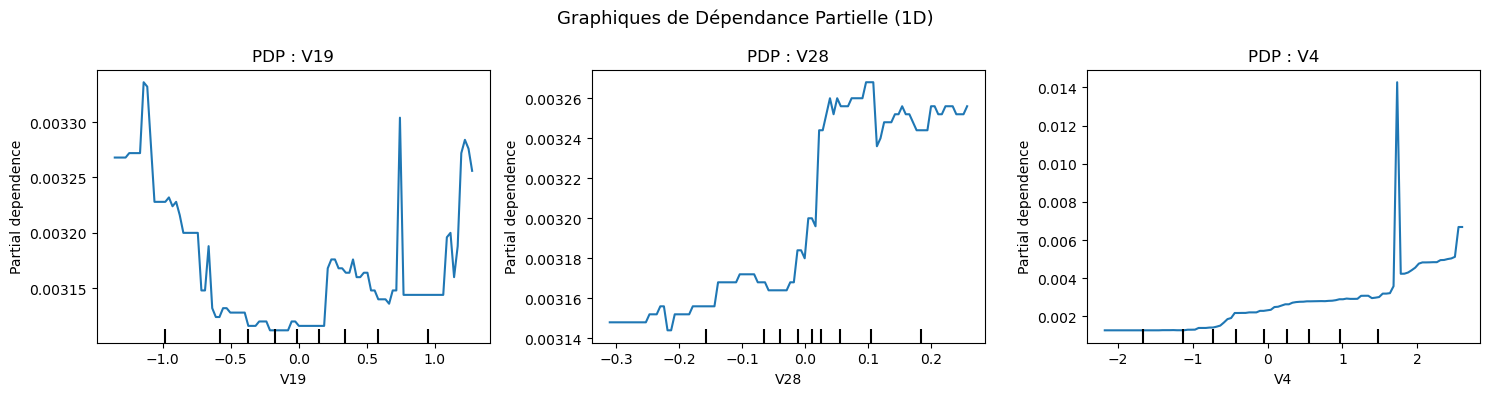

In [43]:
from sklearn.inspection import PartialDependenceDisplay

# On prend les 3 features les plus importantes selon la permutation importance
top3_features = perm_df.head(3)['feature'].tolist()
print(f"PDP pour les 3 features les plus importantes : {top3_features}")

# Utiliser un sous-ensemble de val_X pour accélérer le calcul
val_sample = val_X.sample(n=5000, random_state=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, feature in enumerate(top3_features):
    disp = PartialDependenceDisplay.from_estimator(
        rf_model,
        val_sample,
        [feature],
        ax=axes[i],
        kind='average'
    )
    axes[i].set_title(f'PDP : {feature}')
    axes[i].set_ylabel('Probabilité de fraude (partielle)')

plt.suptitle('Graphiques de Dépendance Partielle (1D)', fontsize=13)
plt.tight_layout()
plt.show()

Les trois graphiques montrent comment la probabilité partielle de fraude évolue en fonction de la valeur de chaque feature.

**V19 :** La courbe est irrégulière et non monotone. Elle démarre haute (≈0.00334) pour les valeurs très négatives de V19 (autour de -1.2), descend vers 0.00313 entre -0.5 et 0, puis remonte légèrement vers 0.0033 pour V19 ≈ 1.2. La plage totale de variation est très étroite (0.00313 à 0.00334), ce qui signifie que l'effet de V19 sur la probabilité de fraude est en réalité faible en valeur absolue, même si c'est la feature la plus "importante" selon la permutation. Cela illustre exactement l'avertissement du cours PDF : une importance élevée ne se traduit pas forcément par un effet visible sur un PDP, surtout quand des interactions complexes entrent en jeu.

**V28 :** La relation est monotone croissante : plus V28 est élevé, plus la probabilité de fraude augmente. La courbe passe de ≈0.00314 pour V28 = -0.3 à ≈0.00327 pour V28 = +0.25. C'est la feature dont le PDP est le plus lisible et le plus propre des trois.

**V4 :** C'est le PDP le plus informatif. La courbe est presque plate et basse (≈0.002) pour toutes les valeurs de V4 inférieures à 1.5, puis elle fait un pic brusque et spectaculaire à ≈0.014 autour de V4 ≈ 1.55, avant de redescendre légèrement. Ce pic indique qu'il existe un seuil précis au-delà duquel V4 devient un signal de fraude très fort. Ce comportement en marche d'escalier est typique des arbres de décision, comme mentionné dans le cours.

#### 3.2.2 PDP à deux dimensions (2D)

Utile pour visualiser les **interactions** entre deux caractéristiques.

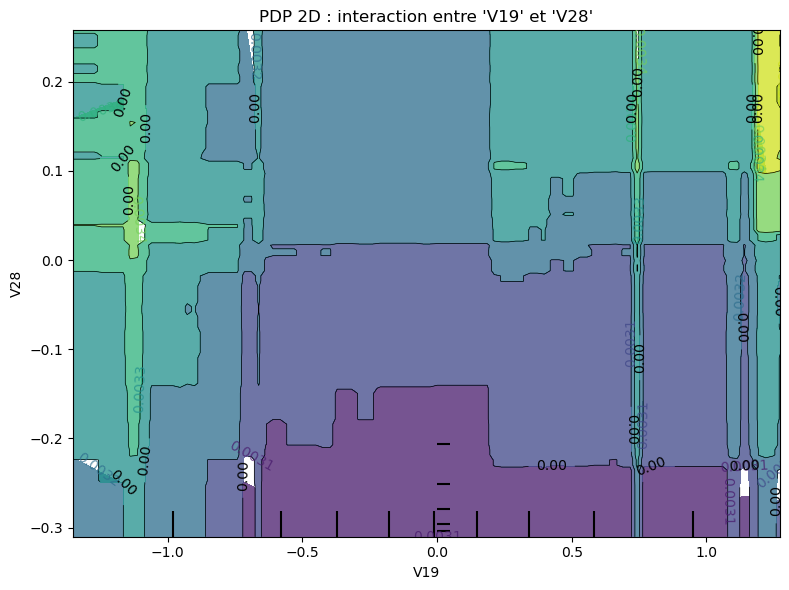

Interprétation : Les courbes de niveau montrent la probabilité de fraude
pour chaque combinaison des deux caractéristiques.


In [45]:
# Environ 8 minutes
# PDP 2D entre les 2 features les plus importantes
feature_pair = [(top3_features[0], top3_features[1])]

fig, ax = plt.subplots(figsize=(8, 6))
disp = PartialDependenceDisplay.from_estimator(
    rf_model,
    val_sample,
    feature_pair,
    ax=ax,
    kind='average'
)

# --- CORRECTION ? ---
# On récupère l'objet "ContourSet" généré par sklearn (situé à l'indice 0,0)
contour_set = disp.contours_[0, 0]

# On redéfinit les étiquettes (labels) des courbes de niveau avec 4 décimales 
# pour éviter le problème des probabilités écrasées à "0.00"
ax.clabel(contour_set, inline=True, fontsize=10, fmt='%.4f')
# ------------------

plt.title(f"PDP 2D : interaction entre '{top3_features[0]}' et '{top3_features[1]}'")
plt.tight_layout()
plt.show()

print("Interprétation : Les courbes de niveau montrent la probabilité de fraude")
print("pour chaque combinaison des deux caractéristiques.")

Les valeurs affichées sur les courbes de niveau (zones) sont les probabilités de fraude partielles, qui sont de l'ordre de 0.003 (0.3%). Arrondies à 2 décimales, elles s'affichent donc toutes comme "0.00". **Ce n'est pas un bug**, c'est une conséquence directe du fort déséquilibre du dataset (492 fraudes sur 284 807 transactions). Les valeurs sont réelles et cohérentes, mais trop petites pour être lisibles avec ce format d'affichage.

Malgré tout, **les couleurs restent exploitables**. Le modèle prend des décisions binaires : "V28 < 0 ou pas ?", "V19 < -0.5 ou pas ?". La zone en bas (V19 négatif, V28 négatif, couleur violette/sombre) correspond à une probabilité de fraude plus élevée. La zone en haut à droite (couleur jaune-verte) correspond à une probabilité différente. On voit aussi quelques zones de rupture en haut à gauche et en bas à droite, signe que les deux variables interagissent à certains endroits.

### 3.3 Valeurs SHAP (SHAP Values)

Les valeurs SHAP (SHapley Additive exPlanations) décomposent une **prédiction individuelle** pour montrer la contribution de chaque caractéristique à ce résultat précis.

**Formule :** Σ(Valeurs SHAP) = Prédiction − Prédiction de base

#### 3.3.1 SHAP Force Plot — Explication d'une transaction individuelle

Forme des valeurs SHAP : (500, 30)
(500 observations × 30 features)

Force plot pour une transaction FRAUDULEUSE (index 119781) :


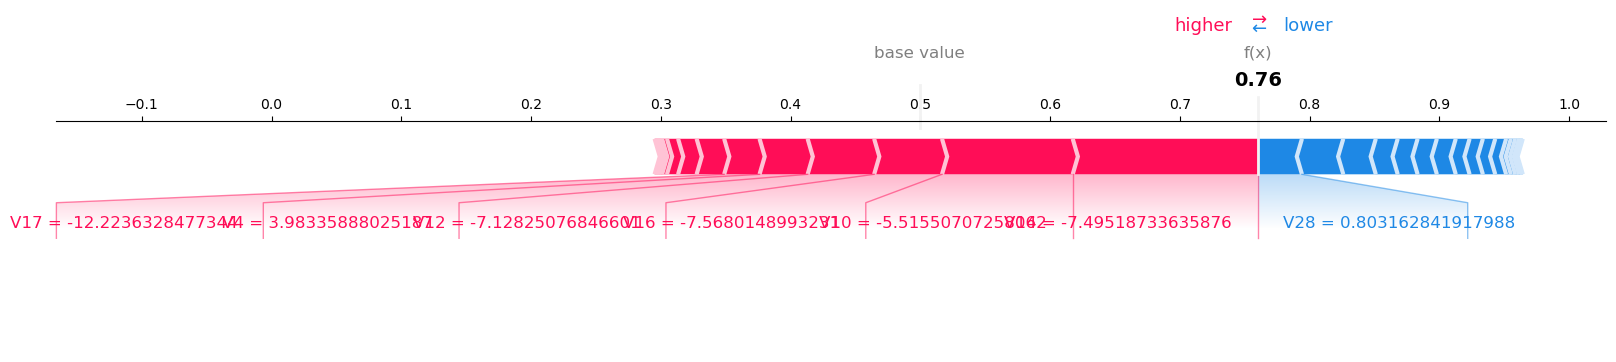

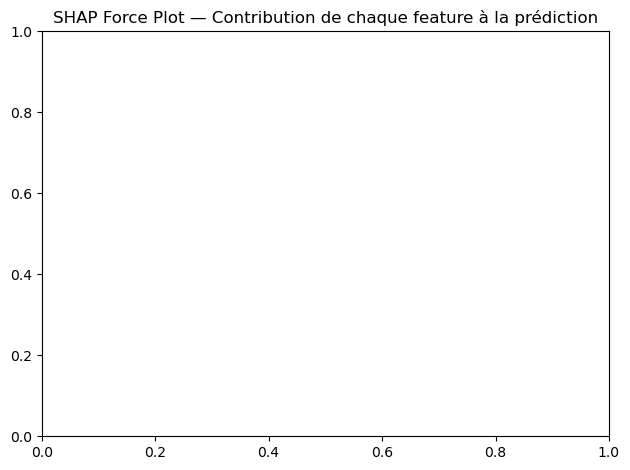

In [46]:
#!pip install "numpy<2.0" "scipy<1.13.0" "shap<0.45.0"
#!pip install shap
#!pip uninstall -y shap scipy numpy
#!pip install "numpy<2.0" "scipy<1.13.0" "shap<0.45.0"
import shap

# Créer un explainer adapté aux modèles à base d'arbres
explainer = shap.TreeExplainer(rf_model)

# Calculer les valeurs SHAP sur un sous-ensemble (pour la vitesse)
val_sample_shap = val_X.sample(n=500, random_state=1)
shap_values = explainer.shap_values(val_sample_shap)

# shap_values est une liste : [valeurs_classe_0, valeurs_classe_1]
# On s'intéresse à la classe 1 (fraude)
shap_values_fraud = shap_values[1]

print(f"Forme des valeurs SHAP : {shap_values_fraud.shape}")
print(f"(500 observations × {len(feature_names)} features)")

# Force plot pour UNE transaction spécifique
# Cherchons une transaction frauduleuse dans notre échantillon
fraud_indices = val_sample_shap.index[val_y[val_sample_shap.index] == 1]
if len(fraud_indices) > 0:
    row_idx = val_sample_shap.index.get_loc(fraud_indices[0])
    print(f"\nForce plot pour une transaction FRAUDULEUSE (index {fraud_indices[0]}) :")
else:
    row_idx = 0
    print("Force plot pour la transaction à l'index 0 :")

shap.initjs()
force_plot = shap.force_plot(
    explainer.expected_value[1],
    shap_values_fraud[row_idx],
    val_sample_shap.iloc[row_idx],
    matplotlib=True
)
plt.title("SHAP Force Plot — Contribution de chaque feature à la prédiction")
plt.tight_layout()
plt.show()

Le graphique interactif (première image) est lisible. La seconde image (cadre blanc vide) est un artefact d'affichage de `matplotlib=True` — elle n'a pas de contenu utile, c'est un problème connu de compatibilité entre `shap.force_plot` et matplotlib dans certaines versions.

**Lecture du Force Plot :**

**f(x) = 0.76 :** le modèle prédit une probabilité de fraude de 76% pour cette transaction.

**Base value ≈ 0.35 :** c'est la probabilité moyenne de fraude sur tout le dataset (la "prédiction de base" sans aucune information sur la transaction).

**Les flèches rouges** poussent vers la droite (augmentent la probabilité de fraude) : V17=-12.22, V4=3.98, V12=-7.13, V16=-7.57, V10=-5.52, V62=-7.50. Ce sont les features qui font que cette transaction ressemble à une fraude.

**La flèche bleue** pousse vers la gauche (réduit la probabilité) : V28=0.80. Cette valeur de V28 joue en faveur de l'authenticité, mais elle n'est pas assez forte pour contrebalancer les signaux rouges.

**Conclusion :** La somme des contributions rouges dépasse largement la contribution bleue de V28, ce qui pousse la prédiction de 0.35 jusqu'à 0.76 → le modèle classe correctement cette transaction comme fraude.

#### 3.3.2 SHAP Summary Plot — Vue globale

Le summary plot agrège les valeurs SHAP de toutes les observations. Il montre l'importance, la **direction** et la **magnitude** de l'effet de chaque feature.

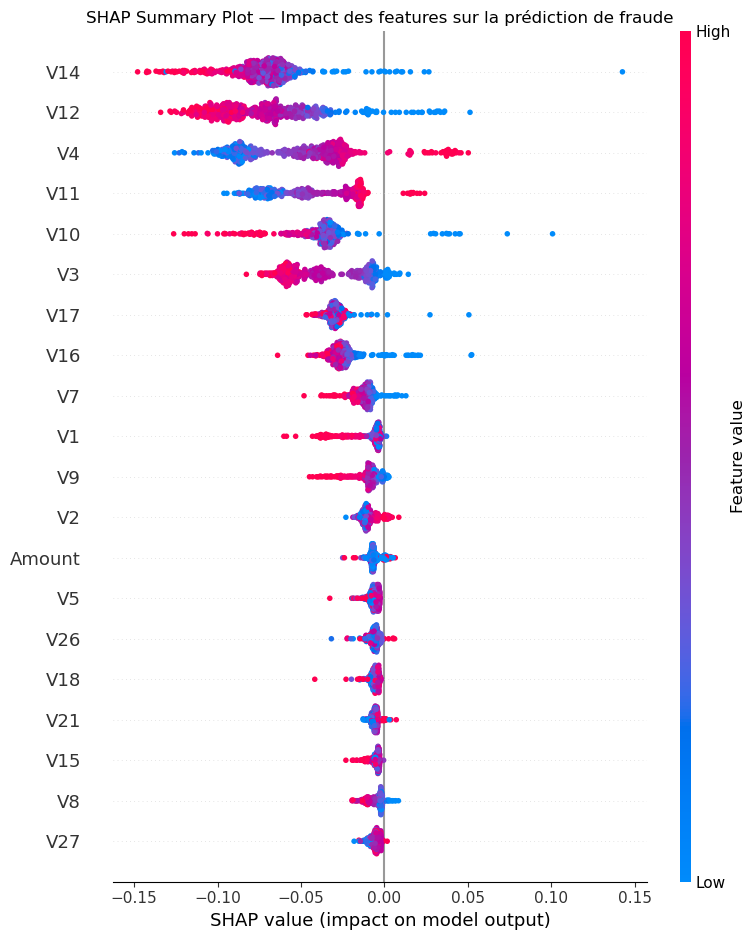

Interprétation :
  - Axe Y     : features triées par importance globale (SHAP mean |value|)
  - Axe X     : valeur SHAP (impact sur la prédiction)
  - Couleur   : Rouge = valeur élevée de la feature, Bleu = valeur faible
  - Points à droite de 0 : poussent vers une prédiction 'fraude'
  - Points à gauche de 0 : poussent vers une prédiction 'authentique'


In [47]:
# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values_fraud,
    val_sample_shap,
    show=False
)
plt.title("SHAP Summary Plot — Impact des features sur la prédiction de fraude")
plt.tight_layout()
plt.show()

print("Interprétation :")
print("  - Axe Y     : features triées par importance globale (SHAP mean |value|)")
print("  - Axe X     : valeur SHAP (impact sur la prédiction)")
print("  - Couleur   : Rouge = valeur élevée de la feature, Bleu = valeur faible")
print("  - Points à droite de 0 : poussent vers une prédiction 'fraude'")
print("  - Points à gauche de 0 : poussent vers une prédiction 'authentique'")

**Différence importante avec la Permutation Importance :** Le SHAP Summary classe V14 en 1ère position, alors que la Permutation Importance avait classé V19 premier. Ces deux méthodes mesurent des choses légèrement différentes (SHAP décompose la prédiction individuelle, la permutation mesure la dégradation globale), et le SHAP est calculé ici sur un sous-échantillon de 500 observations. V14, V12, V4, V11, V10, V3 ressortent comme les features les plus influentes globalement selon SHAP.

**Lecture des patterns par feature :**

**V14 :** Les points rouges (valeur élevée de V14) sont massivement à gauche de 0 (SHAP négatif) → une valeur élevée de V14 réduit la probabilité de fraude. Les points bleus sont dispersés des deux côtés. C'est une feature fortement discriminante.

**V12 :** Même lecture que V14 : les valeurs élevées (rouge) réduisent la probabilité de fraude (SHAP négatif). Il existe quelques points bleus à droite (valeurs faibles de V12 augmentent le risque de fraude).

**V4 :** Comportement inverse : les points rouges sont à droite (SHAP positif) → une valeur élevée de V4 augmente la probabilité de fraude. Cela confirme le pic visible sur le PDP 1D de V4. Les points bleus sont à gauche.

**V11 :** Principalement des points bleus à droite → les valeurs faibles de V11 augmentent le risque de fraude.

**V10 :** Points rouges à gauche et bleus à gauche aussi, avec quelques outliers à droite → relation plus complexe et non monotone.

**Amount :** Apparaît en milieu de classement (13ème environ), avec des points très regroupés autour de 0 — le montant a un effet limité mais réel.

#### 3.3.3 SHAP Dependence Plot — Interactions entre features

Alternative au PDP. Montre l'impact d'une feature (axe Y = valeur SHAP) en fonction de sa valeur (axe X). La couleur révèle une interaction avec une seconde feature.

<Figure size 900x500 with 0 Axes>

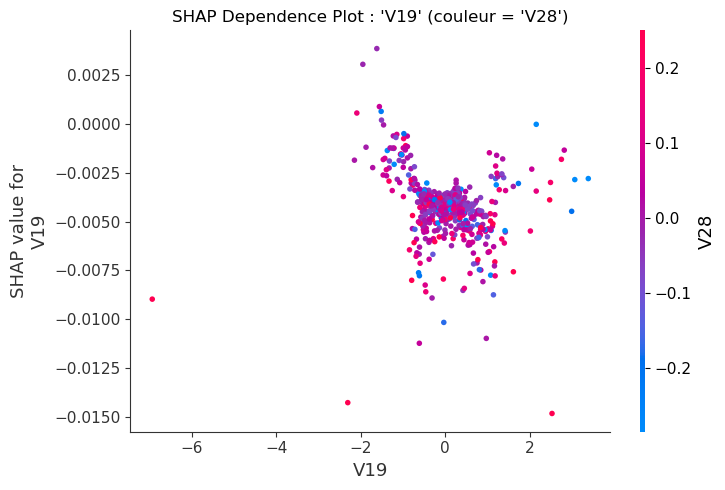

Interprétation :
  - Axe X     : valeur de 'V19'
  - Axe Y     : valeur SHAP (impact sur la prédiction de fraude)
  - Couleur   : valeur de 'V28' (révèle les interactions)
  - Dispersion verticale → interaction forte entre les deux features


In [48]:
# SHAP Dependence Plot pour la feature la plus importante
most_important_feature = perm_df.iloc[0]['feature']
second_feature = perm_df.iloc[1]['feature']

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    most_important_feature,
    shap_values_fraud,
    val_sample_shap,
    interaction_index=second_feature,
    show=False
)
plt.title(f"SHAP Dependence Plot : '{most_important_feature}' (couleur = '{second_feature}')")
plt.tight_layout()
plt.show()

print("Interprétation :")
print(f"  - Axe X     : valeur de '{most_important_feature}'")
print(f"  - Axe Y     : valeur SHAP (impact sur la prédiction de fraude)")
print(f"  - Couleur   : valeur de '{second_feature}' (révèle les interactions)")
print("  - Dispersion verticale → interaction forte entre les deux features")

**Lecture du graphique :**

L'axe X représente la valeur de V19 (de -8 à +3).

L'axe Y représente la valeur SHAP de V19, c'est-à-dire son impact sur la prédiction pour chaque transaction individuelle.

La couleur représente la valeur de V28 (rose = élevée, bleu = faible).

**Ce qu'on observe :**

La quasi-totalité des points a une valeur SHAP négative pour V19, c'est-à-dire que V19 réduit globalement la probabilité de fraude pour la plupart des observations. Cela peut sembler paradoxal puisque V19 était la feature la plus importante selon la permutation, mais rappelons que l'importance par permutation mesure l'impact en cas de perturbation, pas la direction de l'effet.

Il y a deux points isolés avec des valeurs SHAP très négatives (vers -0.010 et -0.015) pour des valeurs extrêmes de V19 (≈ -7 et ≈ 3), qui correspondent probablement à des transactions avec des profils atypiques.

Sur l'interaction avec V28 : Les couleurs (rose/bleu) sont mélangées de façon homogène sur toute la plage de V19, sans structure claire. Cela indique que l'interaction entre V19 et V28 est faible dans ce sous-échantillon. SHAP avait automatiquement sélectionné V28 comme variable d'interaction car c'était la 2ème feature la plus importante, mais le graphique montre que cette interaction est peu prononcée en pratique. Un SHAP Dependence Plot avec V14 ou V4 aurait probablement révélé des interactions plus nettes.

---
## Bilan et Comparaison des Modèles

Récapitulatif des performances (ROC-AUC) de tous les modèles entraînés.

In [49]:
# Comparaison finale
results = {
    'Arbre de Décision (simple)': roc_auc_score(val_y, iowa_model.predict_proba(val_X)[:, 1]),
    f'Arbre de Décision (optimisé, {best_leaves} feuilles)': best_auc,
    'Random Forest (sans pipeline)': roc_auc_score(val_y, rf_val_proba),
    'Random Forest (pipeline normalisé)': roc_auc_score(val_y, pipeline_proba),
    'XGBoost': roc_auc_score(val_y, xgb_proba),
}

print("=" * 55)
print("COMPARAISON DES MODÈLES — ROC-AUC Score")
print("=" * 55)
for model_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 30)
    print(f"  {score:.4f}  {bar}  {model_name}")
print("=" * 55)
print("\nNote : ROC-AUC = 1.0 → parfait, 0.5 → aléatoire")
print("Métrique adaptée au dataset déséquilibré (0.17% de fraudes).")

COMPARAISON DES MODÈLES — ROC-AUC Score
  0.9844  █████████████████████████████  XGBoost
  0.9628  ████████████████████████████  Random Forest (sans pipeline)
  0.9587  ████████████████████████████  Random Forest (pipeline normalisé)
  0.9566  ████████████████████████████  Arbre de Décision (optimisé, 5 feuilles)
  0.9103  ███████████████████████████  Arbre de Décision (simple)

Note : ROC-AUC = 1.0 → parfait, 0.5 → aléatoire
Métrique adaptée au dataset déséquilibré (0.17% de fraudes).


**Conclusions générales :**

**La progression est logique** et conforme aux attentes du cours : chaque modèle plus avancé surpasse le précédent en ROC-AUC.

**XGBoost gagne** sur le ROC-AUC (0.9844), mais son rapport de classification est problématique (precision de 7%). En production réelle, il faudrait ajuster le seuil de décision ou réduire `scale_pos_weight`.

**Le Random Forest sans pipeline est le meilleur compromis :** ROC-AUC de 0.9628, precision 95%, recall 85%, F1 de 0.90 — tous les indicateurs sont équilibrés.

**La normalisation n'aide pas** les modèles à base d'arbres, comme attendu théoriquement.

**Résultat contre-intuitif de l'arbre de décision :** 5 feuilles > 5000 feuilles. C'est l'exemple parfait de l'overfitting décrit dans le cours.